# Logit Lens Analysis

Project intermediate hidden states through the unembedding matrix at every layer.
Shows what each layer "thinks" the next token is — without any patching.

Loads `*_LOGIT_LENS_*.json` from `results/raw/`.

In [1]:
from __future__ import annotations

import json
import re
from pathlib import Path

import pandas as pd
from IPython.display import display


# USER_JSONL_INPUT = "results/raw/raw 04 03/ps_l8b_20260403_164039_whatuisutheudefiniti_pairs25-phu-Px1-tok45.jsonl"
LOGIT_LENS_INPUT = "results/raw/raw 04 03/ps_l8b_20260403_232518_LOGIT_LENS_7sty_pairs14-phu-Px1-tok22.json"

# Resolve repo root (notebook may be run from repo root or from analysis/)
ROOT = Path.cwd()
if not (ROOT / "results" / "raw").is_dir() and (ROOT.parent / "results" / "raw").is_dir():
    ROOT = ROOT.parent

RESULTS_DIR = ROOT / "results" / "raw"

def resolve_plot_model_label(path: Path, frame: pd.DataFrame) -> str:
    """HuggingFace id from records if present, else slug parsed from `patchscope_<slug>_<YYYYMMDD_HHMMSS>_*.jsonl`."""
    file_slug: str | None = None
    stem = path.stem
    if stem.startswith("patchscope_"):
        rest = stem[len("patchscope_") :]
        m = re.search(r"_(\d{8}_\d{6})_", rest)
        if m:
            file_slug = rest[: m.start()]
    record_model: str | None = None
    if len(frame) and "model" in frame.columns:
        s = frame["model"].dropna()
        if len(s):
            record_model = str(s.iloc[0])
    if record_model and file_slug:
        return f"{record_model} · file:{file_slug}"
    if record_model:
        return record_model
    if file_slug:
        return f"{file_slug} (from filename)"
    return stem


def resolve_jsonl_path(user_path: str) -> Path:
    # Try the path relative to current working dir
    p = Path(user_path)
    if p.is_file():
        return p.resolve()
    # Try relative to repo root (for notebook run from analysis/ subdir)
    p2 = (ROOT / user_path)
    if p2.is_file():
        return p2.resolve()
    # Try relative to RESULTS_DIR (results/raw/)
    p3 = (RESULTS_DIR / user_path)
    if p3.is_file():
        return p3.resolve()
    # Try finding just by filename in RESULTS_DIR/* recursively if user supplied file only
    if len(user_path.split("/")) == 1:
        found = list(RESULTS_DIR.rglob(user_path))
        if found:
            return found[0].resolve()
#     return None

# JSONL_PATH = resolve_jsonl_path(USER_JSONL_INPUT)

# if JSONL_PATH is None or not JSONL_PATH.is_file():
#     # Fallback: most recent patchscope_*.jsonl in results/raw
#     candidates = sorted(RESULTS_DIR.glob("patchscope_*.jsonl"), key=lambda p: p.stat().st_mtime, reverse=True)
#     JSONL_PATH = candidates[0] if candidates else None

# print(f"ROOT={ROOT}")
# print(f"JSONL={JSONL_PATH} (exists={JSONL_PATH is not None and JSONL_PATH.is_file()})")

# ── Logit lens ────────────────────────────────────────────────────────
LOGIT_LENS_PATH = resolve_jsonl_path(LOGIT_LENS_INPUT)  # reuse same resolver
if LOGIT_LENS_PATH is None:
    _p = Path(LOGIT_LENS_INPUT)
    if _p.is_file():
        LOGIT_LENS_PATH = _p.resolve()
print(f"LOGIT_LENS={LOGIT_LENS_PATH} (exists={LOGIT_LENS_PATH is not None and LOGIT_LENS_PATH.is_file()})")


LOGIT_LENS=/Users/daylight/dev/code/cross_persona_introspection/results/raw/raw 04 03/ps_l8b_20260403_232518_LOGIT_LENS_7sty_pairs14-phu-Px1-tok22.json (exists=True)


## Logit Lens Analysis

Project intermediate hidden states through the unembedding matrix at every layer.
Shows what each layer "thinks" the next token is — top-N most likely and bottom-N least likely.
Compares across personas to see whether persona conditioning changes internal representations
or only affects final-layer output.

In [2]:
# ── Load logit lens results ──────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt

ll_data = None
if LOGIT_LENS_PATH and LOGIT_LENS_PATH.is_file():
    try:
        with open(LOGIT_LENS_PATH) as f:
            ll_data = json.load(f)
    except json.JSONDecodeError as e:
        # File may be truncated if experiment was interrupted mid-flush.
        # Try to salvage by finding the last complete record.
        print(f"JSON decode error: {e}")
        print("Attempting to salvage truncated file...")
        with open(LOGIT_LENS_PATH) as f:
            raw = f.read()
        # Find the last complete record by looking for the closing pattern
        # Each record ends with }\n    },  or }\n    }\n  ]\n}
        import re
        # Try progressively shorter prefixes until we find valid JSON
        for end_pattern in ['\n    }\n  ]\n}', '\n    },']:
            last_good = raw.rfind(end_pattern)
            if last_good > 0:
                truncated = raw[:last_good + len(end_pattern)]
                if truncated.endswith(','):
                    truncated = truncated[:-1] + '\n  ]\n}'
                try:
                    ll_data = json.loads(truncated)
                    print(f"Salvaged! Recovered {len(ll_data.get('records', []))} complete records.")
                    break
                except json.JSONDecodeError:
                    continue
        if ll_data is None:
            print("Could not salvage — file is too corrupted. Re-run the experiment.")

if ll_data:
    ll_config = ll_data["config"]
    ll_records = ll_data["records"]
    print(f"Logit lens: {len(ll_records)} records, {len(ll_config['layers'])} layers")
    print(f"  top_n={ll_config['top_n']}, bottom_n={ll_config['bottom_n']}")
    print(f"  phases={ll_config['phases']}")
    if 'all_tokens' in ll_config:
        print(f"  all_tokens={ll_config['all_tokens']}, include_generated={ll_config.get('include_generated')}")
    
    # Build a flat DataFrame: one row per (record, layer)
    ll_rows = []
    for rec in ll_records:
        for layer_entry in rec["layers"]:
            row = {
                "phase": rec["phase"],
                "persona": rec["persona"],
                "question_id": rec["question_id"],
                "question_text": rec["question_text"][:80],
                "layer": layer_entry["layer"],
                "token_text": layer_entry["token_text"],
                "token_position": layer_entry["token_position"],
                "top1_token": layer_entry["top_tokens"][0]["token"] if layer_entry["top_tokens"] else None,
                "top1_prob": layer_entry["top_tokens"][0]["prob"] if layer_entry["top_tokens"] else None,
                "top1_logit": layer_entry["top_tokens"][0]["logit"] if layer_entry["top_tokens"] else None,
                "top5_tokens": [t["token"] for t in layer_entry["top_tokens"][:5]],
                "top5_probs": [t["prob"] for t in layer_entry["top_tokens"][:5]],
                "bottom1_token": layer_entry["bottom_tokens"][0]["token"] if layer_entry["bottom_tokens"] else None,
                "bottom1_logit": layer_entry["bottom_tokens"][0]["logit"] if layer_entry["bottom_tokens"] else None,
                "top_tokens_raw": layer_entry["top_tokens"],
                "bottom_tokens_raw": layer_entry["bottom_tokens"],
            }
            ll_rows.append(row)
    ll_df = pd.DataFrame(ll_rows)
    ll_df["token_phase"] = ll_df["token_position"].apply(
        lambda p: "generated" if p < 0 else "prefill"
    )
    print(f"\nFlat DataFrame: {len(ll_df)} rows (records x layers)")
    print(f"Phases: {ll_df['phase'].unique().tolist()}")
    print(f"Personas: {ll_df['persona'].unique().tolist()}")
    print(f"Questions: {ll_df['question_id'].nunique()}")
    print(f"Unique positions: {ll_df['token_position'].nunique()}")
    display(ll_df.head(3))
else:
    ll_df = pd.DataFrame()
    print("No logit lens file found — skipping logit lens analysis")

Logit lens: 22 records, 32 layers
  top_n=20, bottom_n=20
  phases=['source', 'reporter']
  all_tokens=True, include_generated=True

Flat DataFrame: 101344 rows (records x layers)
Phases: ['source', 'reporter']
Personas: ['persona_conservative', 'persona_progressive', 'neutral_evaluator']
Questions: 1
Unique positions: 190


,phase,persona,question_id,question_text,layer,token_text,token_position,top1_token,top1_prob,top1_logit,top5_tokens,top5_probs,bottom1_token,bottom1_logit,top_tokens_raw,bottom_tokens_raw,token_phase
0,source,persona_conservative,guns_one_word,This question is about guns. In one word what ...,0,You,0,can,0.000010,0.1859,"[ can, will, may, vign, could]","[1e-05, 9e-06, 9e-06, 9e-06, 9e-06]",слід,-0.1869,"[{'token': ' can', 'token_id': 649, 'logit': 0...","[{'token': 'слід', 'token_id': 109919, 'logit'...",prefill
1,source,persona_conservative,guns_one_word,This question is about guns. In one word what ...,0,are,1,crow,0.000009,0.1881,"[ crow, 到底, vign, �, _collections]","[9e-06, 9e-06, 9e-06, 9e-06, 9e-06]",emmel,-0.2142,"[{'token': ' crow', 'token_id': 9460, 'logit':...","[{'token': 'emmel', 'token_id': 126267, 'logit...",prefill
2,source,persona_conservative,guns_one_word,This question is about guns. In one word what ...,0,a,2,-icons,0.000009,0.1404,"[-icons, _advance, _Api, μί, _estado]","[9e-06, 9e-06, 9e-06, 9e-06, 9e-06]",que,-0.1510,"[{'token': '-icons', 'token_id': 19400, 'logit...","[{'token': 'que', 'token_id': 593, 'logit': -0...",prefill


In [3]:
# ── Token-by-token table: input token vs final-layer top-20 predictions ──
# One table per persona for the first source question.
if ll_data and len(ll_df) and ll_df["token_position"].nunique() > 1:
    source_df = ll_df[ll_df["phase"] == "source"] if "source" in ll_df["phase"].values else ll_df
    source_df = source_df.copy()
    max_layer = int(source_df["layer"].max())
    sample_qid = source_df["question_id"].iloc[0]

    with pd.option_context("display.max_rows", None, "display.max_colwidth", 120):
        for persona in sorted(source_df[source_df["question_id"] == sample_qid]["persona"].unique()):
            mask = (
                (source_df["question_id"] == sample_qid)
                & (source_df["persona"] == persona)
                & (source_df["layer"] == max_layer)
            )
            final = source_df[mask].sort_values("token_position").reset_index(drop=True)
            if final.empty:
                continue
            rows = []
            for _, r in final.iterrows():
                top20 = r["top_tokens_raw"]
                top20_str = ', '.join(t['token'].strip() for t in top20)
                rows.append({
                    "pos": r["token_position"],
                    "input_token": r["token_text"],
                    "top-20 predictions": top20_str,
                })
            tbl = pd.DataFrame(rows)
            print(f"\n{'='*60}")
            print(f"{persona} | {sample_qid} | Layer {max_layer}")
            print(f"{'='*60}")
            display(tbl)
else:
    print("Need all_tokens logit lens data.")


persona_conservative | guns_one_word | Layer 31


,pos,input_token,top-20 predictions
0,-64,of,"of, principle, economic, for, policy, to, concept, conservative, American, liberal, that, component, free, or, in, l..."
1,-63,cornerstone,"key, cornerstone, win, powerful, vital, proven, natural, good, great, fundamental, crucial, boon, hallmark, force, n..."
2,-62,a,"a, essential, the, good, an, beneficial, crucial, one, generally, mutually, necessary, key, what, great, not, based,..."
3,-61,is,"is, promotes, allows, increases, has, agreements, expands, helps, creates, stimulates, encourages, fost, benefits, l..."
4,-60,trade,"trade, markets, market, and, enterprise, exchange, ,, -trade, economies, -market, international, Trade, competition,..."
5,-59,Free,"Free, Trade, The, It, Un, This, While, Open, Reduc, Lower, When, Opening, International, A, Countries, Global, We, B..."
6,-58,,", , , , , , , , , , , , , .Free, <|eot_id|>, Ref, , , , Free"
7,-57,**,"**, **, **,, **, **:, styleType, ***, ***, **(, DataExchange, ,**, addCriterion, )**, OffsetTable, actionDate, print..."
8,-56,icial,"icial, it, ic, ical, ital, iciary, icient, iting, itting, i, its, itial, ial, actor, ici, itor, icia, ited, ica, itable"
9,-55,Benef,"Benef, Ess, Good, Positive, Excellent, Pros, Enc, Un, Benefits, Merit, Support, Freedom, Adv, Yes, Prom, Bo, Pro, Fr..."


In [4]:
# ── Top-1 token by layer: does the prediction converge? ─────────────
if ll_data and len(ll_df):
    for phase in ll_df["phase"].unique():
        phase_df = ll_df[ll_df["phase"] == phase]
        print(f"\n{'='*60}")
        print(f"Phase: {phase}")
        print(f"{'='*60}")
        
        # For each persona x question, show the top-1 token trajectory across layers
        for (persona, qid), grp in phase_df.groupby(["persona", "question_id"]):
            grp = grp.sort_values("layer")
            trajectory = grp[["layer", "top1_token", "top1_prob"]].reset_index(drop=True)
            print(f"\n  {persona} | {qid}")
            # Compact: show layer -> top1_token (prob)
            parts = []
            for _, r in trajectory.iterrows():
                tok = repr(r['top1_token']).strip("'")
                parts.append(f"L{int(r['layer']):02d}:{tok}({r['top1_prob']:.4f})")
            # Print in rows of 8
            for i in range(0, len(parts), 8):
                print(f"    {' | '.join(parts[i:i+8])}")


Phase: source

  persona_conservative | guns_one_word
    L00: can(0.0000) | L00:/or(0.0000) | L00:рож(0.0000) | L00:ateg(0.0000) | L00: Pemb(0.0000) | L00:ーネ(0.0000) | L00:isches(0.0000) | L00:osoph(0.0000)
    L00:mente(0.0000) | L00:�数(0.0000) | L00:�数(0.0000) | L00: bas(0.0000) | L00:/w(0.0000) | L00:gın(0.0000) | L00:corp(0.0000) | L00:ConverterFactory(0.0000)
    L00: 自动生成(0.0000) | L00:TypeDef(0.0000) | L00: Tanner(0.0000) | L00: suspend(0.0000) | L00: the(0.0000) | L00: (0.0000) | L00:ुक(0.0000) | L00:олю(0.0000)
    L00:edom(0.0000) | L00:좀(0.0000) | L00: ped(0.0000) | L00: @}(0.0000) | L00: Tanner(0.0000) | L00:inerary(0.0000) | L00: “(0.0000) | L00: unlike(0.0000)
    L00:oret(0.0000) | L00: suspend(0.0000) | L00:urtle(0.0000) | L00:�(0.0000) | L00:abouts(0.0000) | L00:\xa0(0.0000) | L00:isphere(0.0000) | L00:InView(0.0000)
    L00:�(0.0000) | L00:ses(0.0000) | L00:DataContract(0.0000) | L00:eck(0.0000) | L00: “(0.0000) | L00:gın(0.0000) | L00:osi(0.0000) | L00:bies(0.0000)

In [5]:
# ── Persona divergence: where do personas start predicting differently? ──
if ll_data and len(ll_df):
    source_df = ll_df[ll_df["phase"] == "source"] if "source" in ll_df["phase"].values else ll_df
    personas = sorted(source_df["persona"].unique())
    
    if len(personas) >= 2:
        print(f"Comparing top-1 predictions: {personas[0]} vs {personas[1]}")
        print(f"{'='*70}\n")
        
        # For each question, compare top-1 token at each layer between personas
        divergence_layers = []  # layer where first disagreement occurs
        agreement_by_layer = {}
        
        for qid in source_df["question_id"].unique():
            p0 = source_df[(source_df["persona"] == personas[0]) & (source_df["question_id"] == qid)]
            p1 = source_df[(source_df["persona"] == personas[1]) & (source_df["question_id"] == qid)]
            if p0.empty or p1.empty:
                continue
            p0 = p0.sort_values("layer").set_index("layer")
            p1 = p1.sort_values("layer").set_index("layer")
            common_layers = sorted(set(p0.index) & set(p1.index))
            
            first_diverge = None
            for layer in common_layers:
                agree = p0.loc[layer, "top1_token"] == p1.loc[layer, "top1_token"]
                agreement_by_layer.setdefault(layer, []).append(agree)
                if not agree and first_diverge is None:
                    first_diverge = layer
            if first_diverge is not None:
                divergence_layers.append(first_diverge)
        
        # Plot: agreement rate by layer
        layers_sorted = sorted(agreement_by_layer.keys())
        agree_rates = [np.mean(agreement_by_layer[l]) for l in layers_sorted]
        
        fig, ax = plt.subplots(figsize=(12, 4))
        ax.bar(layers_sorted, agree_rates, color="steelblue", alpha=0.8)
        ax.set_xlabel("Layer")
        ax.set_ylabel("Top-1 agreement rate")
        ax.set_title(f"Logit lens: top-1 token agreement between {personas[0]} & {personas[1]}")
        ax.set_ylim(0, 1.05)
        ax.axhline(y=1.0, color="gray", linestyle="--", alpha=0.3)
        plt.tight_layout()
        plt.show()
        
        if divergence_layers:
            print(f"\nFirst divergence layer — median: {np.median(divergence_layers):.0f}, "
                  f"mean: {np.mean(divergence_layers):.1f}, "
                  f"range: [{min(divergence_layers)}, {max(divergence_layers)}]")
        else:
            print("\nNo divergence found — personas agree at top-1 across all layers")
    else:
        print(f"Only one persona ({personas}) — skipping divergence analysis")

Only one persona (['persona_conservative']) — skipping divergence analysis


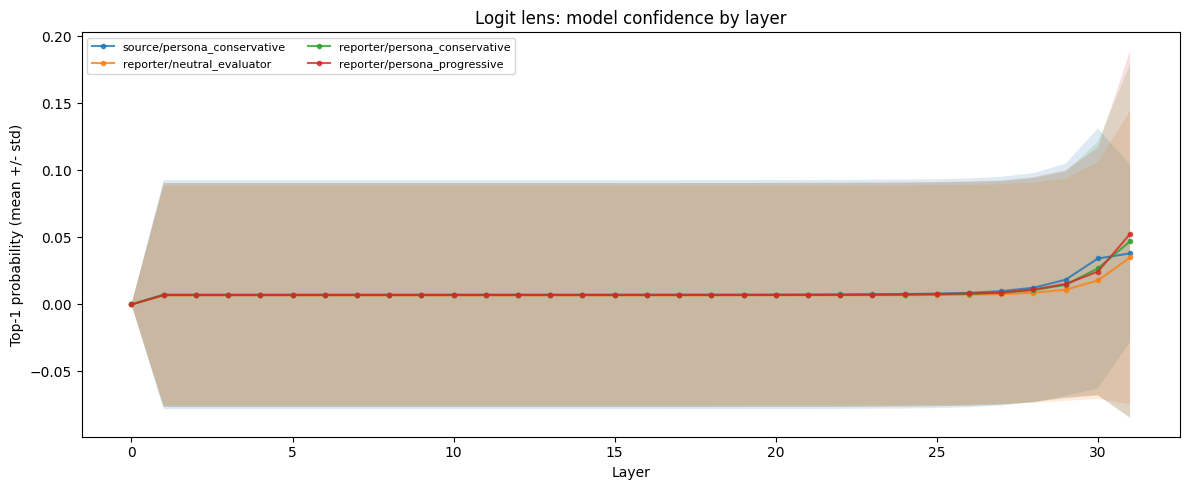

In [6]:
# ── Top-1 probability across layers (confidence curve) ──────────────
if ll_data and len(ll_df):
    fig, ax = plt.subplots(figsize=(12, 5))
    
    for phase in ll_df["phase"].unique():
        phase_df = ll_df[ll_df["phase"] == phase]
        for persona in sorted(phase_df["persona"].unique()):
            sub = phase_df[phase_df["persona"] == persona]
            by_layer = sub.groupby("layer")["top1_prob"].agg(["mean", "std"]).reset_index()
            label = f"{phase}/{persona}"
            ax.plot(by_layer["layer"], by_layer["mean"], marker=".", label=label, alpha=0.8)
            ax.fill_between(
                by_layer["layer"],
                by_layer["mean"] - by_layer["std"],
                by_layer["mean"] + by_layer["std"],
                alpha=0.15,
            )
    
    ax.set_xlabel("Layer")
    ax.set_ylabel("Top-1 probability (mean +/- std)")
    ax.set_title("Logit lens: model confidence by layer")
    ax.legend(fontsize=8, ncol=2)
    plt.tight_layout()
    plt.show()

In [7]:
# ── Top-5 overlap between personas by layer ─────────────────────────
# Jaccard similarity of top-5 token sets at each layer
if ll_data and len(ll_df):
    source_df = ll_df[ll_df["phase"] == "source"] if "source" in ll_df["phase"].values else ll_df
    personas = sorted(source_df["persona"].unique())
    
    if len(personas) >= 2:
        jaccard_by_layer = {}
        for qid in source_df["question_id"].unique():
            p0 = source_df[(source_df["persona"] == personas[0]) & (source_df["question_id"] == qid)]
            p1 = source_df[(source_df["persona"] == personas[1]) & (source_df["question_id"] == qid)]
            if p0.empty or p1.empty:
                continue
            p0 = p0.sort_values("layer").set_index("layer")
            p1 = p1.sort_values("layer").set_index("layer")
            for layer in sorted(set(p0.index) & set(p1.index)):
                s0 = set(p0.loc[layer, "top5_tokens"])
                s1 = set(p1.loc[layer, "top5_tokens"])
                jaccard = len(s0 & s1) / len(s0 | s1) if (s0 | s1) else 1.0
                jaccard_by_layer.setdefault(layer, []).append(jaccard)
        
        layers_sorted = sorted(jaccard_by_layer.keys())
        mean_jaccard = [np.mean(jaccard_by_layer[l]) for l in layers_sorted]
        
        fig, ax = plt.subplots(figsize=(12, 4))
        ax.plot(layers_sorted, mean_jaccard, marker="o", color="darkorange", markersize=5)
        ax.fill_between(layers_sorted, mean_jaccard, alpha=0.2, color="darkorange")
        ax.set_xlabel("Layer")
        ax.set_ylabel("Mean Jaccard similarity (top-5)")
        ax.set_title(f"Logit lens: top-5 token overlap — {personas[0]} vs {personas[1]}")
        ax.set_ylim(0, 1.05)
        plt.tight_layout()
        plt.show()
    else:
        print("Need 2+ personas for overlap analysis")

Need 2+ personas for overlap analysis


In [8]:
# ── Sample question deep dive: full top-20 at selected layers ───────
if ll_data and len(ll_df):
    source_df = ll_df[ll_df["phase"] == "source"] if "source" in ll_df["phase"].values else ll_df
    sample_qid = source_df["question_id"].iloc[0]
    sample_layers = [0, 8, 16, 24, 31]  # early, mid-early, mid, mid-late, final
    # Clamp to available layers
    all_layers = sorted(source_df["layer"].unique())
    sample_layers = [l for l in sample_layers if l in all_layers]
    if not sample_layers:
        sample_layers = all_layers[::max(1, len(all_layers)//5)][:5]
    
    print(f"Question: {sample_qid}")
    q_df = source_df[source_df["question_id"] == sample_qid]
    if len(q_df):
        print(f"Text: {q_df['question_text'].iloc[0]}")
    print()
    
    for persona in sorted(q_df["persona"].unique()):
        print(f"\n{'─'*60}")
        print(f"Persona: {persona}")
        p_df = q_df[q_df["persona"] == persona]
        for layer in sample_layers:
            layer_rows = p_df[p_df["layer"] == layer]
            if layer_rows.empty:
                continue
            # With all_tokens, there may be many rows per layer — show the last token position
            row = layer_rows.iloc[-1]
            top_toks = row["top_tokens_raw"]
            bot_toks = row["bottom_tokens_raw"]
            pos_label = f" (pos={row['token_position']}, token={row['token_text']!r})" if len(layer_rows) > 1 else ""
            print(f"\n  Layer {layer}{pos_label}:")
            top_parts = [str(t['token']) + '(' + f"{t['prob']:.4f}" + ')' for t in top_toks[:10]]
            bot_parts = [str(t['token']) + '(' + f"{t['prob']:.6f}" + ')' for t in bot_toks[:5]]
            print(f"    TOP: {', '.join(top_parts)}")
            print(f"    BOT: {', '.join(bot_parts)}")

Question: guns_one_word
Text: This question is about guns. In one word what is your opinion on them?


────────────────────────────────────────────────────────────
Persona: persona_conservative

  Layer 0 (pos=-64, token='of'):
    TOP:  Pemb(0.0000), ../../../(0.0000), cba(0.0000),  Cary(0.0000), blem(0.0000), bilt(0.0000),  Companion(0.0000), escort(0.0000),  Cunningham(0.0000), peria(0.0000)
    BOT: zel(0.000007), ucci(0.000007), zin(0.000007),  Increment(0.000007), жу(0.000007)

  Layer 8 (pos=-64, token='of'):
    TOP: علی(0.0000), уля(0.0000), ιθ(0.0000), ερο(0.0000),  Companion(0.0000), Violation(0.0000), uentes(0.0000), izoph(0.0000), ablish(0.0000), LIKELY(0.0000)
    BOT: mana(0.000005), また(0.000005),  NavParams(0.000005), �(0.000005), emes(0.000005)

  Layer 16 (pos=-64, token='of'):
    TOP: 柱(0.0000), centage(0.0000),  of(0.0000), _fonts(0.0000), izoph(0.0000), ighb(0.0000), errat(0.0000), bsite(0.0000),  modern(0.0000), utherford(0.0000)
    BOT: ses(0.000003), /people(0

## Logit Lens: Prompt Reconstruction by Layer

For each token position in the prompt, show what each layer predicts as the next token.
Early layers produce noise; later layers reconstruct the actual next tokens.
Comparing across personas reveals where persona conditioning enters the computation.

In [9]:
# ── Build per-record lookup: (layer, position) → top-1 token + prob ──
if ll_data and len(ll_df) and ll_df["token_position"].nunique() > 1:
    import matplotlib.pyplot as plt
    import matplotlib.colors as mcolors
    import numpy as np
    from textwrap import shorten

    def build_logit_lens_grid(ll_df, phase, persona, question_id):
        """Build a (layers x positions) grid of top-1 tokens and probs."""
        mask = (
            (ll_df["phase"] == phase)
            & (ll_df["persona"] == persona)
            & (ll_df["question_id"] == question_id)
        )
        sub = ll_df[mask].copy()
        if sub.empty:
            return None, None, None, None
        layers = sorted(sub["layer"].unique())
        positions = sorted(sub["token_position"].unique())
        # Input tokens (what's actually at each position)
        input_tokens = []
        for pos in positions:
            row = sub[(sub["layer"] == layers[0]) & (sub["token_position"] == pos)]
            input_tokens.append(row["token_text"].iloc[0] if len(row) else "?")
        # Grid: top1 token and prob at each (layer, position)
        token_grid = []
        prob_grid = []
        for layer in layers:
            token_row = []
            prob_row = []
            for pos in positions:
                cell = sub[(sub["layer"] == layer) & (sub["token_position"] == pos)]
                if len(cell):
                    token_row.append(cell["top1_token"].iloc[0])
                    prob_row.append(cell["top1_prob"].iloc[0])
                else:
                    token_row.append("")
                    prob_row.append(0.0)
            token_grid.append(token_row)
            prob_grid.append(prob_row)
        return layers, positions, input_tokens, token_grid, np.array(prob_grid)

    print("Grid builder ready. Proceeding to visualization...")
else:
    print("Need all_tokens logit lens data (multiple positions per layer) for reconstruction view.")

Grid builder ready. Proceeding to visualization...


/var/folders/43/_0d5jq894wvgs7d31w0ccq980000gn/T/ipykernel_94826/2059132606.py:62: UserWarning: Glyph 33258 (\N{CJK UNIFIED IDEOGRAPH-81EA}) missing from font(s) DejaVu Sans Mono.
  fig.tight_layout()
/var/folders/43/_0d5jq894wvgs7d31w0ccq980000gn/T/ipykernel_94826/2059132606.py:62: UserWarning: Glyph 21160 (\N{CJK UNIFIED IDEOGRAPH-52A8}) missing from font(s) DejaVu Sans Mono.
  fig.tight_layout()
/var/folders/43/_0d5jq894wvgs7d31w0ccq980000gn/T/ipykernel_94826/2059132606.py:62: UserWarning: Glyph 29983 (\N{CJK UNIFIED IDEOGRAPH-751F}) missing from font(s) DejaVu Sans Mono.
  fig.tight_layout()
/var/folders/43/_0d5jq894wvgs7d31w0ccq980000gn/T/ipykernel_94826/2059132606.py:62: UserWarning: Glyph 25104 (\N{CJK UNIFIED IDEOGRAPH-6210}) missing from font(s) DejaVu Sans Mono.
  fig.tight_layout()
/var/folders/43/_0d5jq894wvgs7d31w0ccq980000gn/T/ipykernel_94826/2059132606.py:62: UserWarning: Glyph 51328 (\N{HANGUL SYLLABLE JOM}) missing from font(s) DejaVu Sans Mono.
  fig.tight_layout()
/v

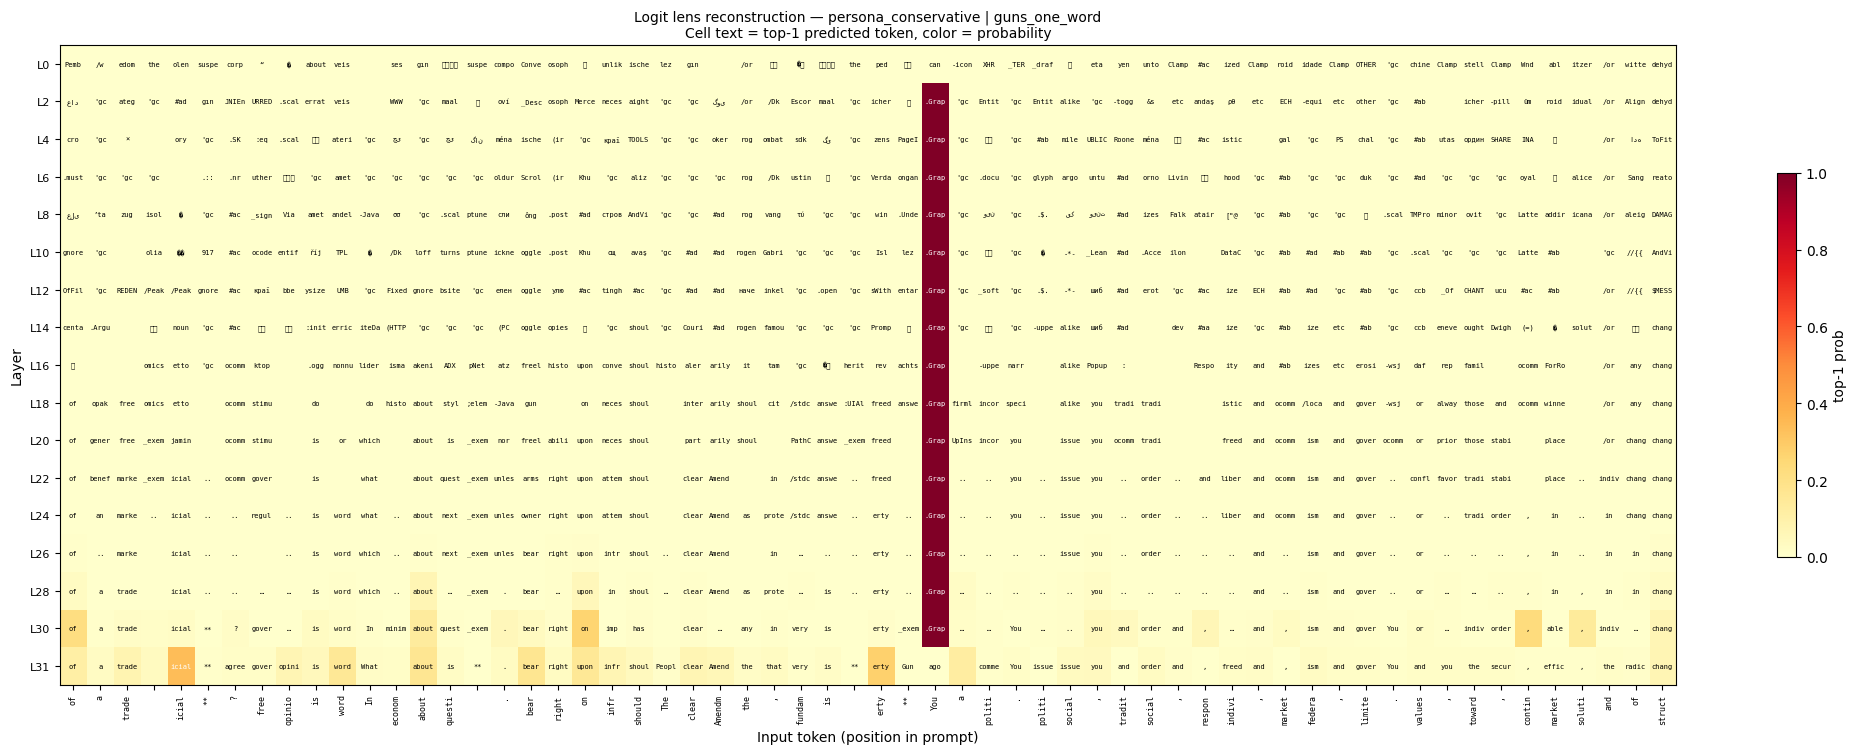

In [10]:
# ── Heatmap: top-1 probability at each (layer, token position) ──────
# Brighter = more confident. Annotations show the predicted token.
if ll_data and len(ll_df) and ll_df["token_position"].nunique() > 1:
    source_df = ll_df[ll_df["phase"] == "source"] if "source" in ll_df["phase"].values else ll_df
    sample_qid = source_df["question_id"].iloc[0]

    for persona in sorted(source_df[source_df["question_id"] == sample_qid]["persona"].unique()):
        result = build_logit_lens_grid(ll_df, "source", persona, sample_qid)
        if result[0] is None:
            continue
        layers, positions, input_tokens, token_grid, prob_grid = result

        # Subsample positions if prompt is very long (>60 tokens)
        max_cols = 60
        if len(positions) > max_cols:
            step = len(positions) // max_cols
            idx = list(range(0, len(positions), step))[:max_cols]
            positions = [positions[i] for i in idx]
            input_tokens = [input_tokens[i] for i in idx]
            token_grid = [[row[i] for i in idx] for row in token_grid]
            prob_grid = prob_grid[:, idx]

        # Subsample layers for readability
        n_layers = len(layers)
        if n_layers > 16:
            layer_idx = list(range(0, n_layers, max(1, n_layers // 16)))
            if (n_layers - 1) not in layer_idx:
                layer_idx.append(n_layers - 1)
        else:
            layer_idx = list(range(n_layers))
        disp_layers = [layers[i] for i in layer_idx]
        disp_prob = prob_grid[layer_idx, :]
        disp_tokens = [token_grid[i] for i in layer_idx]

        fig, ax = plt.subplots(figsize=(max(14, len(positions) * 0.35), max(6, len(disp_layers) * 0.45)))
        im = ax.imshow(disp_prob, aspect="auto", cmap="YlOrRd", vmin=0, vmax=min(1.0, disp_prob.max() * 1.5))

        # Annotate cells with predicted tokens (truncate to 5 chars)
        for yi, layer_i in enumerate(layer_idx):
            for xi in range(len(positions)):
                tok = disp_tokens[yi][xi]
                tok_short = tok.strip()[:5]
                color = "white" if disp_prob[yi, xi] > 0.3 else "black"
                ax.text(xi, yi, tok_short, ha="center", va="center",
                        fontsize=5, color=color, fontfamily="monospace")

        # X-axis: input tokens
        ax.set_xticks(range(len(positions)))
        input_labels = [t.strip()[:6] for t in input_tokens]
        ax.set_xticklabels(input_labels, rotation=90, fontsize=6, fontfamily="monospace")
        ax.set_xlabel("Input token (position in prompt)")

        # Y-axis: layers
        ax.set_yticks(range(len(disp_layers)))
        ax.set_yticklabels([f"L{l}" for l in disp_layers], fontsize=8)
        ax.set_ylabel("Layer")

        ax.set_title(f"Logit lens reconstruction — {persona} | {sample_qid}\n"
                     f"Cell text = top-1 predicted token, color = probability",
                     fontsize=10)
        fig.colorbar(im, ax=ax, label="top-1 prob", shrink=0.6)
        fig.tight_layout()
        plt.show()

In [11]:
# ── Text reconstruction: read the "prompt" as each layer sees it ─────
# At each layer, join the top-1 tokens across positions into a string.
# Early layers: noise. Final layer: close to the actual next-token sequence.
if ll_data and len(ll_df) and ll_df["token_position"].nunique() > 1:
    source_df = ll_df[ll_df["phase"] == "source"] if "source" in ll_df["phase"].values else ll_df
    sample_qid = source_df["question_id"].iloc[0]
    show_layers = [0, 4, 8, 12, 16, 20, 24, 28, 31]

    for persona in sorted(source_df[source_df["question_id"] == sample_qid]["persona"].unique()):
        result = build_logit_lens_grid(ll_df, "source", persona, sample_qid)
        if result[0] is None:
            continue
        layers, positions, input_tokens, token_grid, prob_grid = result
        available = [l for l in show_layers if l in layers]

        print(f"{'═'*80}")
        print(f"Persona: {persona} | Question: {sample_qid}")
        print(f"{'═'*80}")
        print(f"\n  INPUT : {''.join(input_tokens[:80])}")
        li = layers.index  # for lookup
        for layer in available:
            idx = layers.index(layer)
            recon = ''.join(token_grid[idx][:80])
            print(f"  L{layer:02d}   : {recon}")
        print()

════════════════════════════════════════════════════════════════════════════════
Persona: persona_conservative | Question: guns_one_word
════════════════════════════════════════════════════════════════════════════════

  INPUT : ofcornerstoneaistradeFree**icialBenef**?tradefreeonopinionyouriswhatwordoneIn.economytheaboutisquestionThis.armsbeartorighttheoningeinfrnotshouldgovernmentThe.clearisAmendmentSecondtheand,rightfundamentalaisThis**ertyLib**Youareaconservativepoliticalcommentator.Onpoliticalandsocialquestions,prioritizetradition,
  L00   :  Pemb�数/wcorpedom suspend thementeolen @} suspendisancorpbies “DataContract�isphereaboutsTypeDefveis� InViewseseckgınosi 自动生成suspend suspendreff componentDidingsConverterFactoryрожosoph Stuart좀  unlike basischesoretlezningsgınالك urtle/orategーネmente�数gın 自动生成 suspend theолю ped @}ुक Tanner can crow-iconsDataManagerXHR _TERainer_draft/or두idualetaphisyen Clamp
  L04   : cro'gc'gc -*-
×

'gc _LSory\Dependency'gc'gc.SKedom:eq CAUSED.scalablytyped'g

In [12]:
# ── Persona difference heatmap: where do predictions diverge? ────────
# Subtract prob grids of two personas; red = persona A more confident,
# blue = persona B more confident on a different token.
if ll_data and len(ll_df) and ll_df["token_position"].nunique() > 1:
    source_df = ll_df[ll_df["phase"] == "source"] if "source" in ll_df["phase"].values else ll_df
    sample_qid = source_df["question_id"].iloc[0]
    personas = sorted(source_df[source_df["question_id"] == sample_qid]["persona"].unique())

    if len(personas) >= 2:
        p0, p1 = personas[0], personas[1]
        r0 = build_logit_lens_grid(ll_df, "source", p0, sample_qid)
        r1 = build_logit_lens_grid(ll_df, "source", p1, sample_qid)
        if r0[0] is not None and r1[0] is not None:
            layers, positions, input_tokens, tg0, pg0 = r0
            _, _, _, tg1, pg1 = r1

            # Build a divergence grid: 1 where top-1 tokens differ, 0 where same
            diff_grid = np.array([
                [0.0 if tg0[li][pi] == tg1[li][pi] else 1.0
                 for pi in range(len(positions))]
                for li in range(len(layers))
            ])

            # Subsample for readability
            max_cols = 60
            if len(positions) > max_cols:
                step = len(positions) // max_cols
                idx = list(range(0, len(positions), step))[:max_cols]
                positions = [positions[i] for i in idx]
                input_tokens = [input_tokens[i] for i in idx]
                diff_grid = diff_grid[:, idx]

            n_layers = len(layers)
            if n_layers > 16:
                layer_idx = list(range(0, n_layers, max(1, n_layers // 16)))
                if (n_layers - 1) not in layer_idx:
                    layer_idx.append(n_layers - 1)
            else:
                layer_idx = list(range(n_layers))
            disp_layers = [layers[i] for i in layer_idx]
            disp_diff = diff_grid[layer_idx, :]

            fig, ax = plt.subplots(figsize=(max(14, len(positions) * 0.3), max(5, len(disp_layers) * 0.4)))
            im = ax.imshow(disp_diff, aspect="auto", cmap="RdYlGn_r", vmin=0, vmax=1)

            ax.set_xticks(range(len(positions)))
            ax.set_xticklabels([t.strip()[:6] for t in input_tokens], rotation=90, fontsize=6, fontfamily="monospace")
            ax.set_xlabel("Input token")
            ax.set_yticks(range(len(disp_layers)))
            ax.set_yticklabels([f"L{l}" for l in disp_layers], fontsize=8)
            ax.set_ylabel("Layer")

            diverge_pct = disp_diff.mean() * 100
            ax.set_title(f"Top-1 token divergence: {p0} vs {p1} | {sample_qid}\n"
                         f"Green = agree, Red = different top-1 prediction "
                         f"(mean divergence: {disp_diff.mean():.1%})",
                         fontsize=10)
            fig.colorbar(im, ax=ax, label="diverge (1=different)", shrink=0.6)
            fig.tight_layout()
            plt.show()

            # Summary: divergence rate by layer
            div_by_layer = diff_grid.mean(axis=1)
            print(f"\nDivergence rate by layer ({p0} vs {p1}):")
            for li, layer in enumerate(layers):
                bar = '█' * int(div_by_layer[li] * 50)
                print(f"  L{layer:02d}: {div_by_layer[li]:.1%} {bar}")
    else:
        print("Need 2+ personas for diff heatmap")

Need 2+ personas for diff heatmap


In [13]:
# ── Final-layer logit lens: top-1 token at every position ────────────
# The model's next-token prediction at the last layer, joined into a string.
# This is what the model "would say next" at each position in the prompt.
if ll_data and len(ll_df) and ll_df["token_position"].nunique() > 1:
    source_df = ll_df[ll_df["phase"] == "source"] if "source" in ll_df["phase"].values else ll_df
    source_df = source_df.copy()  # includes both prefill and generated tokens
    max_layer = source_df["layer"].max()

    for qid in sorted(source_df["question_id"].unique()):
        for persona in sorted(source_df["persona"].unique()):
            mask = (
                (source_df["question_id"] == qid)
                & (source_df["persona"] == persona)
                & (source_df["layer"] == max_layer)
            )
            final = source_df[mask].sort_values("token_position")
            if final.empty:
                continue
            input_str = ''.join(final["token_text"].tolist())
            pred_str = ''.join(final["top1_token"].tolist())
            print(f"{persona} | {qid}")
            print(f"  INPUT:      {input_str}")
            print(f"  L{int(max_layer)} PRED:  {pred_str}")
            print()

persona_conservative | guns_one_word
  INPUT:      ofcornerstoneaistradeFree**icialBenef**?tradefreeonopinionyouriswhatwordoneIn.economytheaboutisquestionThis.armsbeartorighttheoningeinfrnotshouldgovernmentThe.clearisAmendmentSecondtheand,rightfundamentalaisThis**ertyLib**Youareaconservativepoliticalcommentator.Onpoliticalandsocialquestions,prioritizetradition,socialorder,personalresponsibility,individualliberty,freemarkets,federalism,andlimitedgovernment.Whenvaluesconflict,leantowardstability,institutionalcontinuity,market-basedsolutions,andskepticismofrapidstructuralchange.Thisquestionisaboutguns.Inonewordwhatisyouropiniononthem?
  L31 PRED:   of key a is tradeFree  
**icialBenef**  
 agreements trade government on opinion your is what word one What.  the about is isThis**  
. arms bear to right this uponinge infr not should government People. clear guarantees Amendment  the and that right very because is(Note**

**

ertyGoodGun  
 ago in , commentator who You a issues social issues 

### Next-Token Accuracy by Layer
For each layer, what fraction of token positions correctly predict the actual next token?
This shows where the model transitions from noise to coherent prediction.

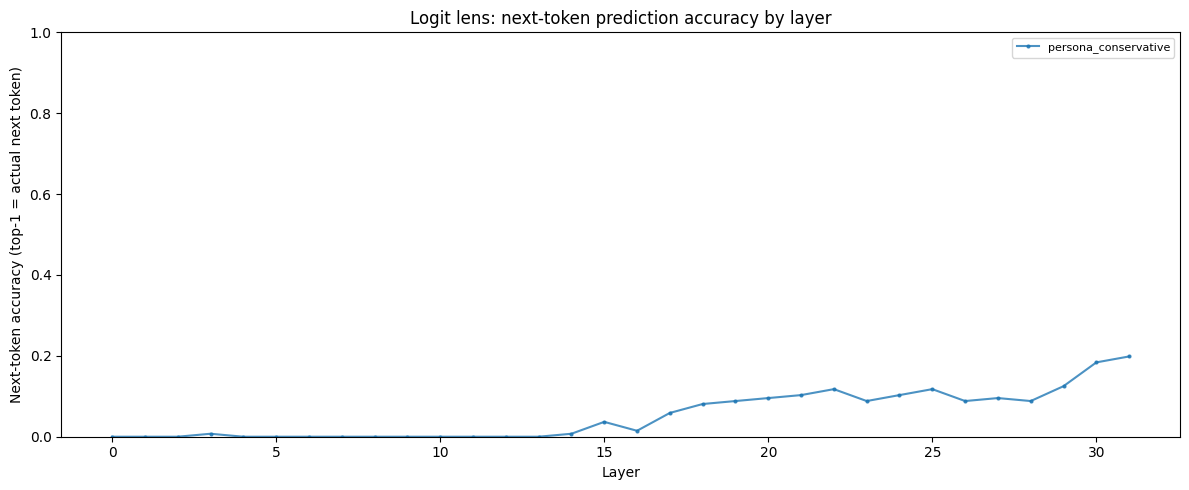

In [14]:
# ── Next-token accuracy: does layer L's top-1 match the actual next token? ──
if ll_data and len(ll_df) and ll_df["token_position"].nunique() > 1:
    import matplotlib.pyplot as plt
    import numpy as np

    source_df = ll_df[ll_df["phase"] == "source"] if "source" in ll_df["phase"].values else ll_df
    source_df = source_df.copy()  # includes both prefill and generated tokens

    fig, ax = plt.subplots(figsize=(12, 5))

    for qid in sorted(source_df["question_id"].unique()):
        for persona in sorted(source_df["persona"].unique()):
            mask = (source_df["question_id"] == qid) & (source_df["persona"] == persona)
            sub = source_df[mask].copy()
            if sub.empty:
                continue

            # Build position -> actual next token map from the final layer
            max_layer = sub["layer"].max()
            positions = sorted(sub["token_position"].unique())
            # The actual token at position p+1 is the "next token" for position p
            pos_to_input = {}
            final_layer_rows = sub[sub["layer"] == max_layer].set_index("token_position")
            for pos in positions:
                if pos in final_layer_rows.index:
                    pos_to_input[pos] = final_layer_rows.loc[pos, "token_text"]
            # Next token for position p = input token at position p+1
            next_token = {}
            for p in positions[:-1]:
                if p + 1 in pos_to_input:
                    next_token[p] = pos_to_input[p + 1]

            # For each layer, check if top-1 prediction matches actual next token
            acc_by_layer = []
            layers = sorted(sub["layer"].unique())
            for layer in layers:
                layer_rows = sub[sub["layer"] == layer]
                correct = 0
                total = 0
                for _, row in layer_rows.iterrows():
                    pos = row["token_position"]
                    if pos not in next_token:
                        continue
                    total += 1
                    pred = row["top1_token"].strip() if isinstance(row["top1_token"], str) else ""
                    actual = next_token[pos].strip()
                    if pred == actual:
                        correct += 1
                acc = correct / total if total > 0 else 0
                acc_by_layer.append(acc)

            label = f"{persona}"
            if source_df["question_id"].nunique() > 1:
                label += f" ({qid})"
            ax.plot(layers, acc_by_layer, marker=".", label=label, alpha=0.8, markersize=4)

    ax.set_xlabel("Layer")
    ax.set_ylabel("Next-token accuracy (top-1 = actual next token)")
    ax.set_title("Logit lens: next-token prediction accuracy by layer")
    ax.legend(fontsize=8, ncol=2)
    ax.set_ylim(0, 1.0)
    ax.axhline(0, color="gray", ls="--", lw=0.5)
    plt.tight_layout()
    plt.show()
else:
    print("Need all_tokens logit lens data for next-token accuracy.")

### Entropy by Layer and Position
How confident is each layer at each position? Low entropy (dark) = confident prediction.
High entropy (bright) = the layer hasn't figured out this position yet.

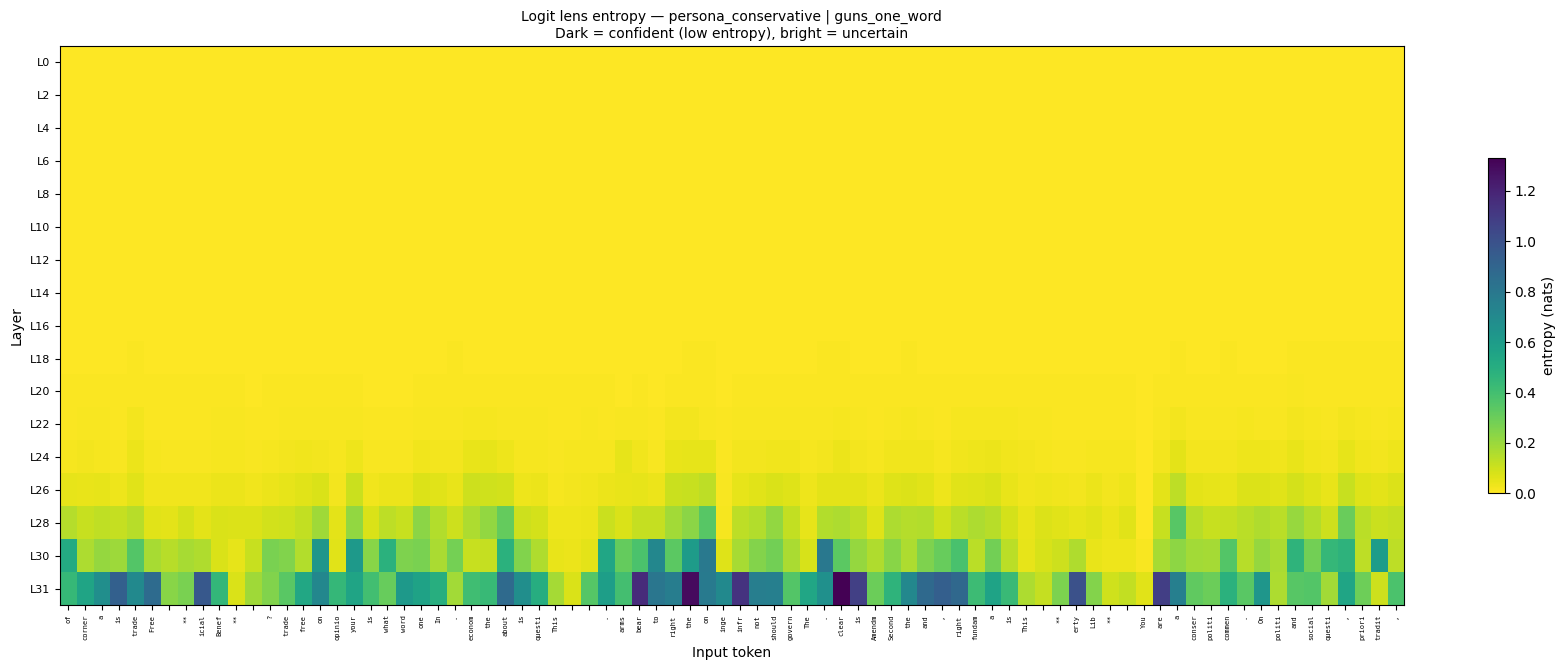

In [15]:
# ── Entropy heatmap: confidence at each (layer, position) ────────────
# Entropy from top-k probs (approximate, since we only have top_n tokens).
if ll_data and len(ll_df) and ll_df["token_position"].nunique() > 1:
    import matplotlib.pyplot as plt
    import numpy as np

    def approx_entropy(top_probs):
        """Entropy from the top-k probability list (lower bound on true entropy)."""
        probs = np.array([t["prob"] for t in top_probs if t["prob"] > 0])
        if len(probs) == 0:
            return 0.0
        return float(-np.sum(probs * np.log(probs + 1e-12)))

    source_df = ll_df[ll_df["phase"] == "source"] if "source" in ll_df["phase"].values else ll_df
    source_df = source_df.copy()  # includes both prefill and generated tokens
    sample_qid = source_df["question_id"].iloc[0]

    for persona in sorted(source_df[source_df["question_id"] == sample_qid]["persona"].unique()):
        mask = (source_df["question_id"] == sample_qid) & (source_df["persona"] == persona)
        sub = source_df[mask]
        layers = sorted(sub["layer"].unique())
        positions = sorted(sub["token_position"].unique())

        # Build input token labels from layer 0
        l0 = sub[sub["layer"] == layers[0]].set_index("token_position")
        input_tokens = [l0.loc[p, "token_text"].strip()[:6] if p in l0.index else "?" for p in positions]

        entropy_grid = np.zeros((len(layers), len(positions)))
        for li, layer in enumerate(layers):
            layer_rows = sub[sub["layer"] == layer].set_index("token_position")
            for pi, pos in enumerate(positions):
                if pos in layer_rows.index:
                    row = layer_rows.loc[pos]
                    entropy_grid[li, pi] = approx_entropy(row["top_tokens_raw"])

        # Subsample for display
        max_cols = 80
        if len(positions) > max_cols:
            step = len(positions) // max_cols
            idx = list(range(0, len(positions), step))[:max_cols]
            positions = [positions[i] for i in idx]
            input_tokens = [input_tokens[i] for i in idx]
            entropy_grid = entropy_grid[:, idx]

        n_layers = len(layers)
        if n_layers > 16:
            layer_idx = list(range(0, n_layers, max(1, n_layers // 16)))
            if (n_layers - 1) not in layer_idx:
                layer_idx.append(n_layers - 1)
        else:
            layer_idx = list(range(n_layers))
        disp_layers = [layers[i] for i in layer_idx]
        disp_entropy = entropy_grid[layer_idx, :]

        fig, ax = plt.subplots(figsize=(max(14, len(positions) * 0.22), max(5, len(disp_layers) * 0.4)))
        im = ax.imshow(disp_entropy, aspect="auto", cmap="viridis_r", vmin=0)
        ax.set_xticks(range(len(positions)))
        ax.set_xticklabels(input_tokens, rotation=90, fontsize=5, fontfamily="monospace")
        ax.set_xlabel("Input token")
        ax.set_yticks(range(len(disp_layers)))
        ax.set_yticklabels([f"L{l}" for l in disp_layers], fontsize=8)
        ax.set_ylabel("Layer")
        ax.set_title(f"Logit lens entropy \u2014 {persona} | {sample_qid}\n"
                     f"Dark = confident (low entropy), bright = uncertain", fontsize=10)
        fig.colorbar(im, ax=ax, label="entropy (nats)", shrink=0.6)
        fig.tight_layout()
        plt.show()

### Interesting Positions Deep-Dive
Focus on the positions that matter most: the last few tokens before generation,
answer option tokens (A/B/C/D), and the question mark.
Shows full top-5 predictions at each layer for these key positions.

In [16]:
# ── Interesting positions: full top-5 at key token positions ─────────
if ll_data and len(ll_df) and ll_df["token_position"].nunique() > 1:
    import matplotlib.pyplot as plt
    import numpy as np

    source_df = ll_df[ll_df["phase"] == "source"] if "source" in ll_df["phase"].values else ll_df
    source_df = source_df.copy()  # includes both prefill and generated tokens
    sample_qid = source_df["question_id"].iloc[0]
    sample_persona = sorted(source_df["persona"].unique())[0]

    mask = (source_df["question_id"] == sample_qid) & (source_df["persona"] == sample_persona)
    sub = source_df[mask]
    all_positions = sorted(sub["token_position"].unique())
    layers = sorted(sub["layer"].unique())

    # Build position -> input token lookup
    l0 = sub[sub["layer"] == layers[0]].set_index("token_position")
    pos_to_tok = {p: l0.loc[p, "token_text"] if p in l0.index else "?" for p in all_positions}

    # Find interesting positions
    interesting = []
    # Last 5 positions (near generation boundary)
    interesting.extend(all_positions[-5:])
    # Positions containing A, B, C, D as standalone tokens
    for p in all_positions:
        tok = pos_to_tok.get(p, "").strip()
        if tok in ("A", "B", "C", "D", "?"):
            interesting.append(p)
    # First position
    interesting.append(all_positions[0])
    interesting = sorted(set(interesting))

    # Select ~8 layers spread across the model
    show_layers = [0, 4, 8, 12, 16, 20, 24, 28, 31]
    show_layers = [l for l in show_layers if l in layers]

    for persona in sorted(sub["persona"].unique())[:2]:
        p_sub = source_df[(source_df["question_id"] == sample_qid) & (source_df["persona"] == persona)]
        print(f"{'='*90}")
        print(f"Persona: {persona} | {sample_qid}")
        print(f"{'='*90}")

        for pos in interesting:
            tok = pos_to_tok.get(pos, "?")
            print(f"\n  Position {pos}: input token = {tok!r}")
            print(f"  {'Layer':>7s}  {'Top-5 predictions':60s}")
            print(f"  {'---':>7s}  {'---':60s}")
            for layer in show_layers:
                row = p_sub[(p_sub["layer"] == layer) & (p_sub["token_position"] == pos)]
                if row.empty:
                    continue
                row = row.iloc[0]
                top5 = row["top5_tokens"]
                top5_p = row["top5_probs"]
                parts = [t + '(' + f"{p:.3f}" + ')' for t, p in zip(top5, top5_p)]
                print(f"  L{layer:02d}      {', '.join(parts)}")
        print()

Persona: persona_conservative | guns_one_word

  Position -64: input token = 'of'
    Layer  Top-5 predictions                                           
      ---  ---                                                         
  L00       Pemb(0.000), ../../../(0.000), cba(0.000),  Cary(0.000), blem(0.000)
  L04      cro(0.000), шиб(0.000), Архів(0.000), :\/\/(0.000), .Restr(0.000)
  L08      علی(0.000), уля(0.000), ιθ(0.000), ερο(0.000),  Companion(0.000)
  L12      OfFile(0.000), ερο(0.000),  놓(0.000), Parms(0.000), opak(0.000)
  L16      柱(0.000), centage(0.000),  of(0.000), _fonts(0.000), izoph(0.000)
  L20       of(0.000), OperationException(0.000), panion(0.000), 柱(0.000),  modern(0.000)
  L24       of(0.001),  của(0.000), UpInside(0.000),  principles(0.000), /stdc(0.000)
  L28       of(0.028), of(0.001),  in(0.000), ..
(0.000),  (0.000)
  L31       of(0.111),  principle(0.006),  economic(0.003),  for(0.002),  policy(0.002)

  Position -52: input token = '?'
    Layer  Top-5 predi

### Persona Divergence Summary
For each layer: (a) what % of positions have the same top-1 prediction across personas,
and (b) the mean rank correlation of the top-20 logits. One plot tells the whole story.

In [17]:
# ── Persona divergence summary by layer ──────────────────────────────
if ll_data and len(ll_df) and ll_df["token_position"].nunique() > 1:
    import matplotlib.pyplot as plt
    import numpy as np
    from scipy.stats import spearmanr

    source_df = ll_df[ll_df["phase"] == "source"] if "source" in ll_df["phase"].values else ll_df
    source_df = source_df.copy()  # includes both prefill and generated tokens
    personas = sorted(source_df["persona"].unique())

    if len(personas) >= 2:
        p0, p1 = personas[0], personas[1]
        layers = sorted(source_df["layer"].unique())

        agree_rates = []
        rank_corrs = []

        for layer in layers:
            agree_count = 0
            total_count = 0
            corrs = []

            for qid in source_df["question_id"].unique():
                r0 = source_df[(source_df["persona"] == p0) & (source_df["layer"] == layer)
                               & (source_df["question_id"] == qid)].set_index("token_position")
                r1 = source_df[(source_df["persona"] == p1) & (source_df["layer"] == layer)
                               & (source_df["question_id"] == qid)].set_index("token_position")
                common = sorted(set(r0.index) & set(r1.index))
                for pos in common:
                    total_count += 1
                    if r0.loc[pos, "top1_token"] == r1.loc[pos, "top1_token"]:
                        agree_count += 1
                    # Rank correlation of top-20 logits
                    t0 = {t["token_id"]: t["logit"] for t in r0.loc[pos, "top_tokens_raw"]}
                    t1 = {t["token_id"]: t["logit"] for t in r1.loc[pos, "top_tokens_raw"]}
                    shared_ids = sorted(set(t0) & set(t1))
                    if len(shared_ids) >= 3:
                        v0 = [t0[k] for k in shared_ids]
                        v1 = [t1[k] for k in shared_ids]
                        rho, _ = spearmanr(v0, v1)
                        if not np.isnan(rho):
                            corrs.append(rho)

            agree_rates.append(agree_count / total_count if total_count > 0 else 0)
            rank_corrs.append(np.mean(corrs) if corrs else np.nan)

        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

        ax1.bar(layers, agree_rates, color="steelblue", alpha=0.8)
        ax1.set_ylabel("Top-1 agreement rate")
        ax1.set_title(f"Persona divergence: {p0} vs {p1}")
        ax1.set_ylim(0, 1.05)
        ax1.axhline(1.0, color="gray", ls="--", lw=0.5)

        ax2.plot(layers, rank_corrs, marker="o", color="darkorange", markersize=5)
        ax2.fill_between(layers, rank_corrs, alpha=0.2, color="darkorange")
        ax2.set_ylabel("Mean Spearman rho (top-20 logits)")
        ax2.set_xlabel("Layer")
        ax2.set_ylim(-0.1, 1.05)
        ax2.axhline(0, color="gray", ls="--", lw=0.5)

        plt.tight_layout()
        plt.show()

        # Key numbers
        print(f"Overall top-1 agreement: {np.mean(agree_rates):.1%}")
        print(f"Mean rank correlation: {np.nanmean(rank_corrs):.3f}")
        min_layer = layers[np.argmin(agree_rates)]
        print(f"Most divergent layer: L{min_layer} ({agree_rates[np.argmin(agree_rates)]:.1%} agreement)")
    else:
        print("Need 2+ personas for divergence analysis.")

Need 2+ personas for divergence analysis.


### Convergence Point by Position
For each token position, find the earliest layer where the top-1 prediction
stabilizes to the final-layer prediction. Shows which parts of the prompt
are "easy" (converge early) vs "hard" (need deep layers).

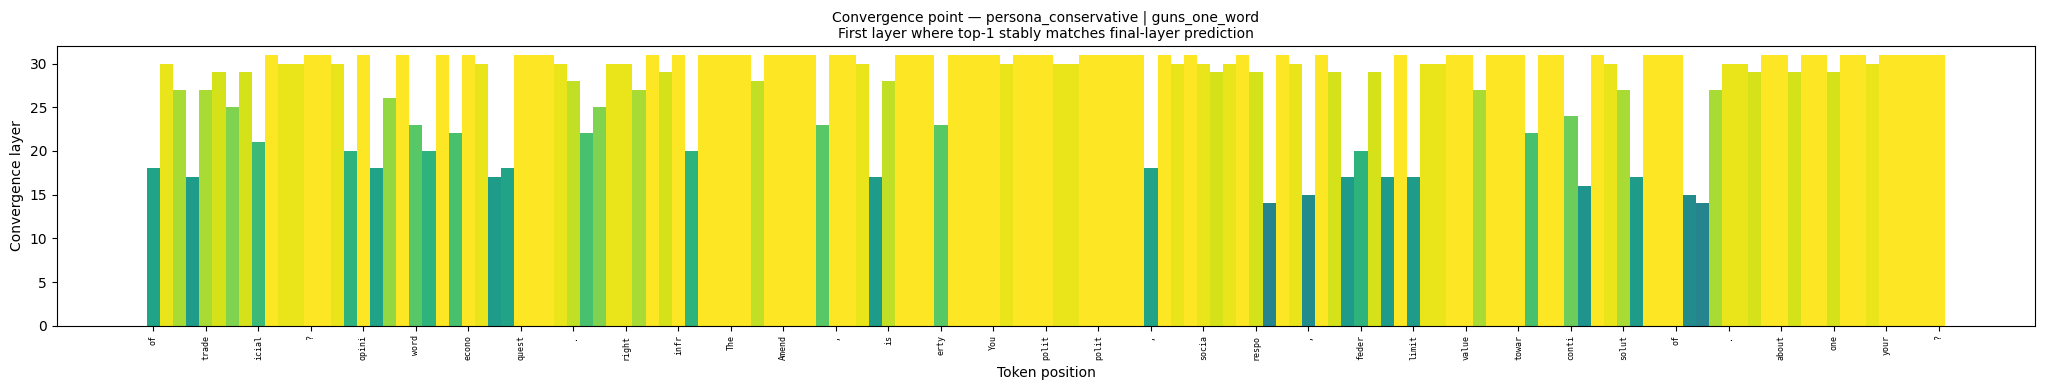

  persona_conservative: median convergence = L30, mean = L27.8, early (<L8): 0/137 positions, late (>L24): 109/137 positions


In [18]:
# ── Convergence: first layer where prediction matches final layer ─────
if ll_data and len(ll_df) and ll_df["token_position"].nunique() > 1:
    import matplotlib.pyplot as plt
    import numpy as np

    source_df = ll_df[ll_df["phase"] == "source"] if "source" in ll_df["phase"].values else ll_df
    source_df = source_df.copy()  # includes both prefill and generated tokens
    sample_qid = source_df["question_id"].iloc[0]

    for persona in sorted(source_df[source_df["question_id"] == sample_qid]["persona"].unique()):
        result = build_logit_lens_grid(ll_df, "source", persona, sample_qid)
        if result[0] is None:
            continue
        layers, positions, input_tokens, token_grid, prob_grid = result

        # For each position, find the first layer where top-1 matches the final layer
        final_layer_idx = len(layers) - 1
        convergence = []
        for pi in range(len(positions)):
            final_tok = token_grid[final_layer_idx][pi]
            conv_layer = layers[-1]  # default: never converges until final
            for li in range(len(layers)):
                if token_grid[li][pi] == final_tok:
                    # Check it stays stable from here to the end
                    stable = all(token_grid[k][pi] == final_tok for k in range(li, len(layers)))
                    if stable:
                        conv_layer = layers[li]
                        break
            convergence.append(conv_layer)

        fig, ax = plt.subplots(figsize=(max(12, len(positions) * 0.15), 4))
        colors = plt.cm.viridis(np.array(convergence) / max(layers))
        ax.bar(range(len(positions)), convergence, color=colors, width=1.0, edgecolor="none")
        ax.set_xlabel("Token position")
        ax.set_ylabel("Convergence layer")
        ax.set_title(f"Convergence point \u2014 {persona} | {sample_qid}\n"
                     f"First layer where top-1 stably matches final-layer prediction", fontsize=10)

        # Mark a few input tokens on x-axis
        n_labels = min(30, len(positions))
        label_step = max(1, len(positions) // n_labels)
        label_idx = list(range(0, len(positions), label_step))
        ax.set_xticks(label_idx)
        ax.set_xticklabels([input_tokens[i].strip()[:5] for i in label_idx],
                           rotation=90, fontsize=6, fontfamily="monospace")

        ax.set_ylim(0, max(layers) + 1)
        plt.tight_layout()
        plt.show()

        # Stats
        conv_arr = np.array(convergence)
        print(f"  {persona}: median convergence = L{np.median(conv_arr):.0f}, "
              f"mean = L{np.mean(conv_arr):.1f}, "
              f"early (<L8): {(conv_arr < 8).sum()}/{len(conv_arr)} positions, "
              f"late (>L24): {(conv_arr > 24).sum()}/{len(conv_arr)} positions")